In [2]:
import os, json, pickle
import soundfile

# load segmentation_dict 
segmentation_file = "/data/home/scv7387/run/tv_series_plus/3D-Speaker/egs/3dspeaker/speaker-diarization/runs/debug/exp_video_overlap/json/segmentation.pkl"
with open(segmentation_file, 'rb') as f:
    segmentations = pickle.load(f)
print(segmentations.keys())
segmentation = segmentations['E01']
print(segmentation['segmentations'].shape)
print(segmentation['count_arr'].shape)
print(len(segmentation['valid_field']))
print(segmentation['count_arr'][:10,:])

# load audio
audio, sample_rate = soundfile.read("/data/home/scv7387/run/tv_series_plus/dataset/debug/raw/E01.wav")
time_duration = len(audio) / sample_rate
print(f"Audio duration: {time_duration} seconds; Sample rate: {sample_rate} Hz")

dict_keys(['E01'])
(1369, 589, 3)
(81660, 2)
338
[[0.03096875 0.        ]
 [0.04784375 0.        ]
 [0.06471875 0.        ]
 [0.08159375 0.        ]
 [0.09846875 0.        ]
 [0.11534375 0.        ]
 [0.13221875 0.        ]
 [0.14909375 0.        ]
 [0.16596875 0.        ]
 [0.18284375 0.        ]]
Audio duration: 1377.984 seconds; Sample rate: 16000 Hz


In [ ]:
import numpy as np

# 获取不同值及其数量
unique_values, counts = np.unique(segmentation['count_arr'][:,0], return_counts=True)

# 打印结果
for value, count in zip(unique_values, counts):
  print(f"Value: {value}, Count: {count}")

Value: 0, Count: 28298
Value: 1, Count: 52694
Value: 2, Count: 668


### 按照pyannote/segmentation-3.0预测说话人数量情况，调整语音起止时间后的语音时长分布

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_durations(subseg_path):
    with open(subseg_path, 'r') as f:
        subseg_data = json.load(f)
    durations = []
    for key, item in subseg_data.items():
        start = item['start']
        end = item['stop']
        durations.append(end - start)
    return durations

def plot_dur_hist(TV_name):
    subseg_path_old = f'/data/home/scv7387/run/tv_series_plus/3D-Speaker/egs/3dspeaker/speaker-diarization/runs/{TV_name}/exp_video/json/subseg.json'
    subseg_path_new = f'/data/home/scv7387/run/tv_series_plus/3D-Speaker/egs/3dspeaker/speaker-diarization/runs/{TV_name}/exp_video_overlap/json/subseg.json'

    dur_old = load_durations(subseg_path_old)
    dur_new = load_durations(subseg_path_new)
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, max(max(dur_old), max(dur_new)) + 0.1, 0.1)
    plt.hist(dur_old, bins=bins, alpha=0.5, label='From subtitle')
    plt.hist(dur_new, bins=bins, alpha=0.5, label='From subtitle + overlap detection')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Frequency')
    plt.title(f'Audio Segment Duration Distribution for {TV_name}')
    plt.legend()
    plt.grid(True)
    plt.show()


#### 原始情况

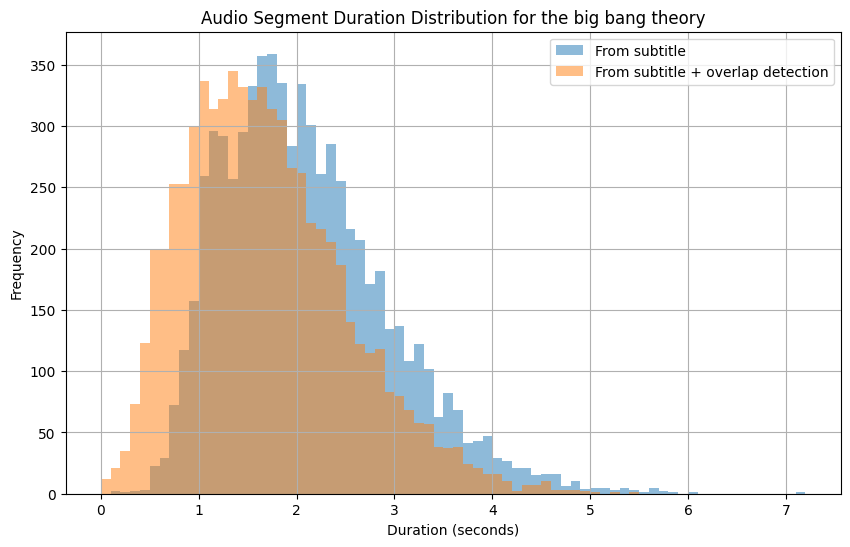

In [10]:
plot_dur_hist("the big bang theory")

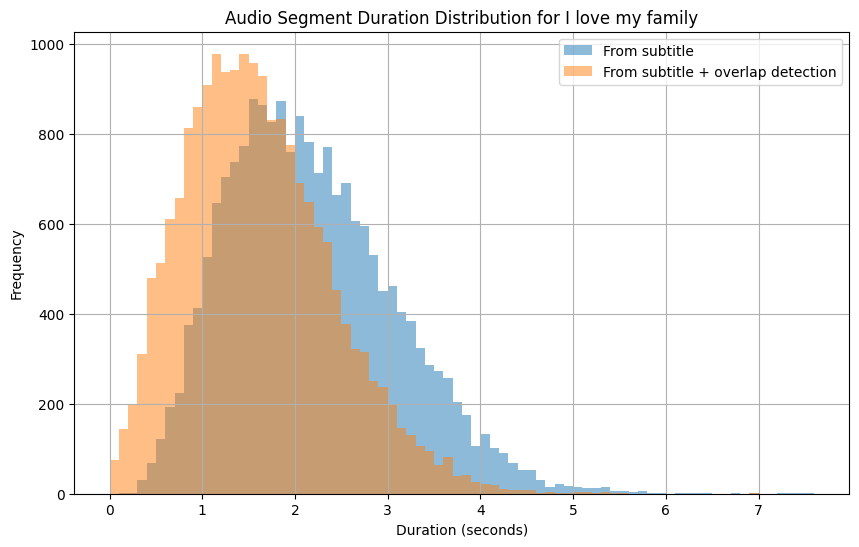

In [11]:
plot_dur_hist("I love my family")

#### 如果修正后短于1s, 则维持原状

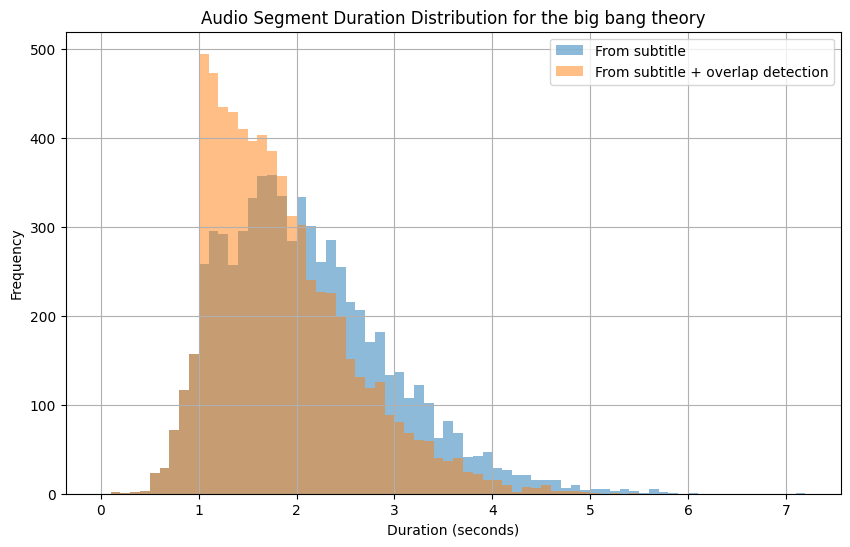

In [8]:
plot_dur_hist("the big bang theory")

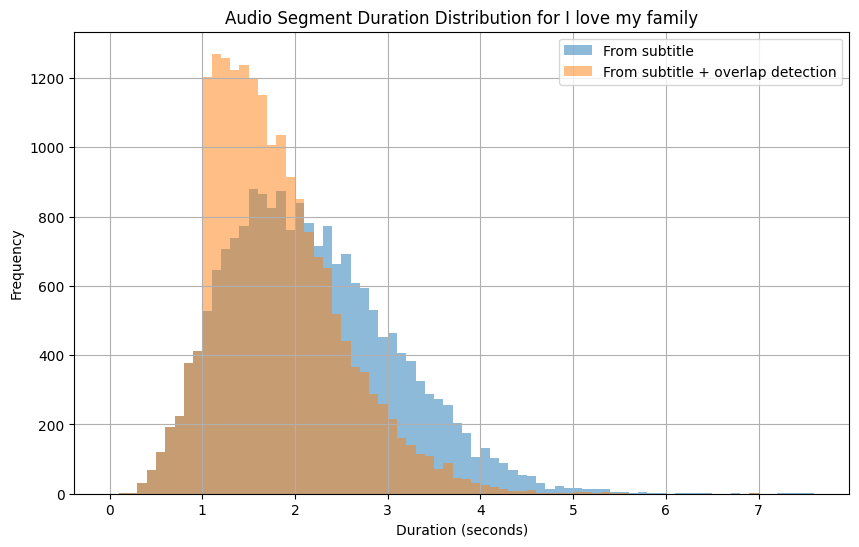

In [9]:
plot_dur_hist("I love my family")